# Revenue Analysis

This notebook analyzes revenue performance between 2016 and 2018 using month sales metrics, growth trends and averange order value (AOV).

Objectives:
- Analyze revenue evolution over time.
- Detect growth patterns and seasonality.
- Understand purchasing behavior trends.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.database import get_engine
import pandas as pd

In [9]:
engine = get_engine()
with open('../sql/kpi/revenue/revenue_monthly.sql', 'r') as f:
    query_rm=f.read()

with open('../sql/kpi/revenue/revenue_growth.sql', 'r') as f:
    query_growth=f.read()

with open('../sql/kpi/customer/avg_order_value_monthly.sql', 'r') as f:
    query_aov=f.read()

df_revenue_monthly = pd.read_sql_query(query_rm, engine)
df_revenue_growth = pd.read_sql_query(query_growth, engine)
df_aov_monthly = pd.read_sql_query(query_aov, engine)

df_revenue_monthly = df_revenue_monthly.dropna(subset=['month'])
df_revenue_growth = df_revenue_growth.dropna(subset=['month'])
df_aov_monthly = df_aov_monthly.dropna(subset=['month'])


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

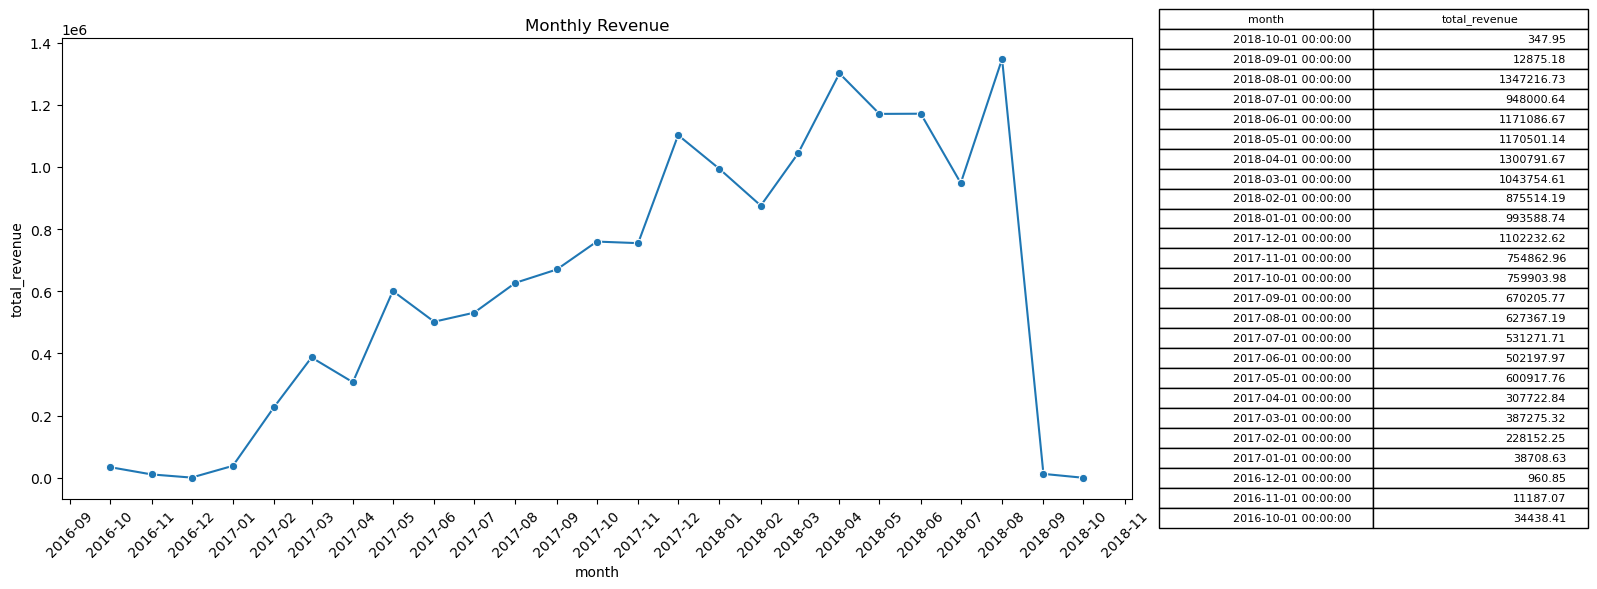

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,6), gridspec_kw={'width_ratios': [3, 1]})

sns.lineplot(data=df_revenue_monthly, x='month', y='total_revenue', marker='o', ax=axes[0])
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[0].set_title('Monthly Revenue')
axes[0].tick_params(axis='x', rotation=45)

axes[1].axis('off')
table = axes[1].table(
    cellText=df_revenue_monthly.values,
    colLabels=df_revenue_monthly.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)

plt.tight_layout()
plt.show()

The monthly revenue chart shows sustained growth trend from late 2016 throught August 2018, which represents the peak revenue period with approximately 1.35 million in sales.
Throughout the analyzed period, revenue increased progressively, especially during 2017 and early 2018, although some intermediate fluctuations can also be observed.
However, during the final months displayed in the chart, there is a sharp decline in revenue, particularly in September and October 2018. Due to the magnitude of the decrease compared to previous months, this behavior could indicate:
 - partial absence of data.
 - monthly reporting not yet fully consolidated.
 - exceptional business event.

For this reason, it is not possible to immediately conclude that there is a downward trend. Instead, a deeper analysis of these specific months would be required.

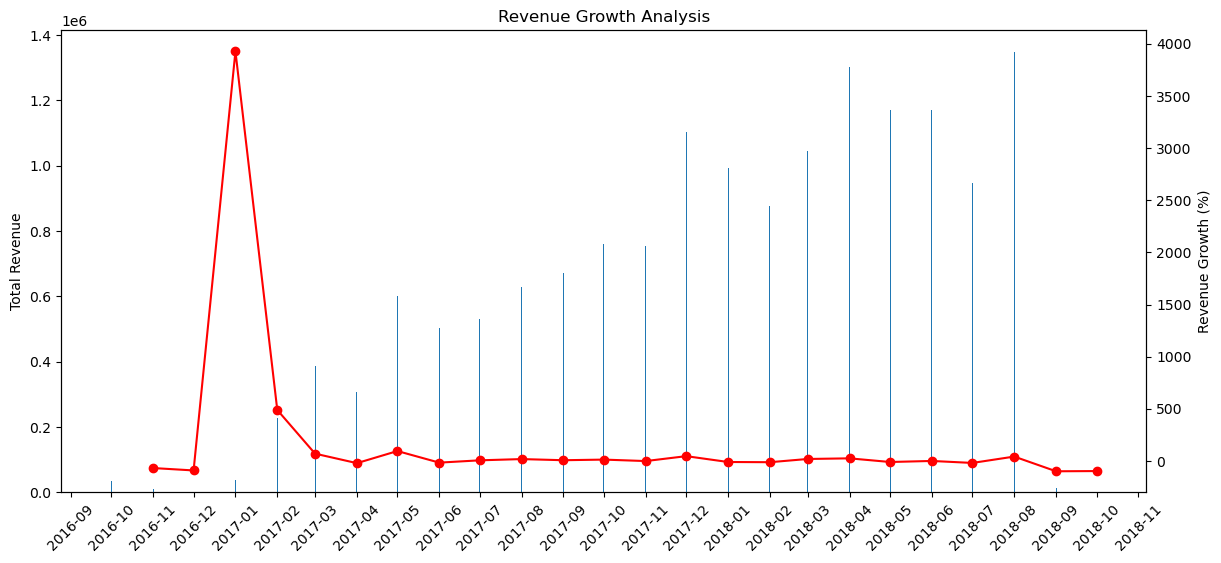

In [6]:
df = df_revenue_growth.sort_values('month')
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month')

df['revenue_growth_pct'] = (
    (
        df['total_revenue'] - df['previous_month_revenue']
    )
    / df['previous_month_revenue']
).round(2) * 100

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    df['month'],
    df['total_revenue']
)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.set_title('Revenue Growth Analysis')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Total Revenue')

ax2 = ax1.twinx()

ax2.plot(
    df['month'],
    df['revenue_growth_pct'],
    marker='o',
    color='red'
)
ax2.set_ylabel('Revenue Growth (%)')

plt.xticks(rotation=45)

plt.show()


The chart shows an exceptionally high positive growth spike between November 2016 and January 2017. However, despite the large percentage increase in revenue growth, the absolute revenue values during this period were still relatively low compared to later periods in the dataset. This indicates that small initial revenue values amplified the growth percentage significantly.

After this initial phase, the revenue growth rate becomes more stable throughout most of 2017 and early 2018, with moderate positive and negative fluctuations. During this period, total revenue continues to increase overall, suggesting a sustained business expansion.

A significant change occurs between August and September 2018, where total revenue drops abruptly. Interestingly, although the revenue values collapse dramatically, the growth-rate line does not display an equally extreme visual change due to the scale distortion generated by the very high growth percentages observed in the early stages of the dataset.

Therefore, while the chart clearly reveals an abnormal decline in revenue during the final months, it still does not provide enough evidence to determine the exact cause of the decrease.

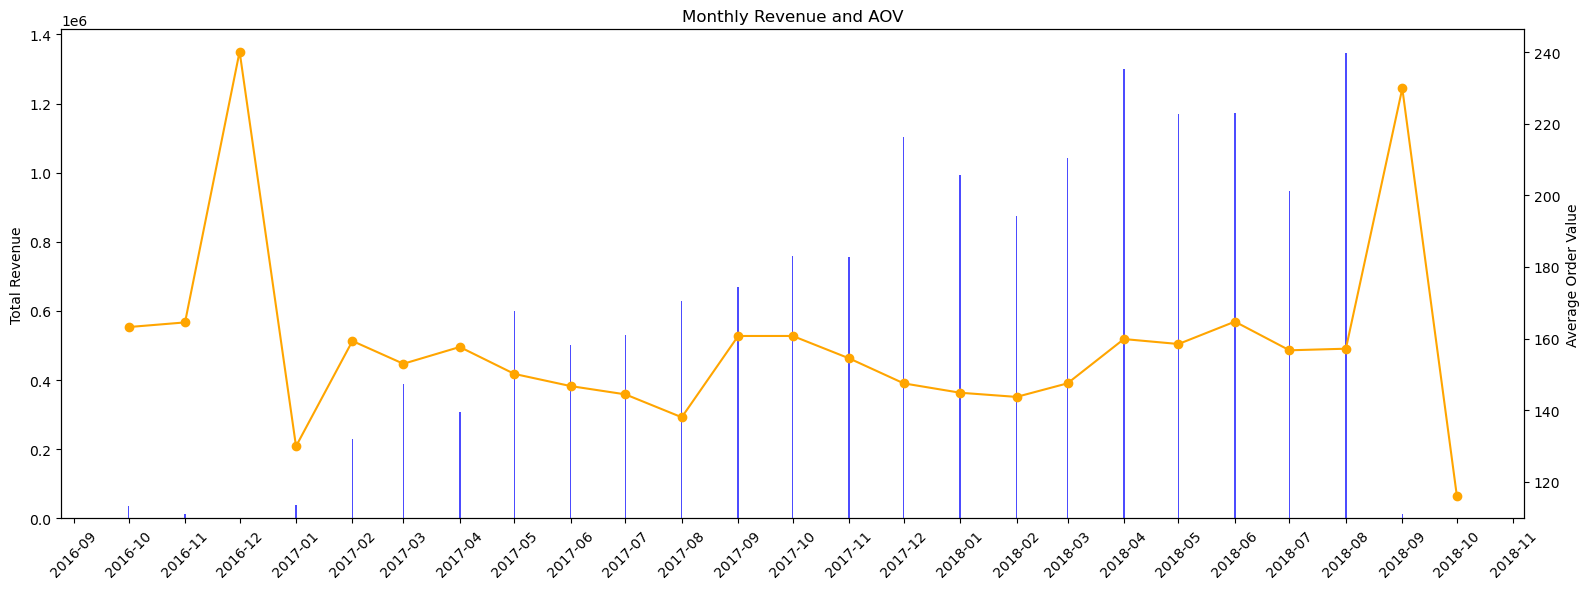

In [20]:
df_analysis = pd.merge(
    df_revenue_monthly,
    df_aov_monthly,
    on='month',
    how='inner'
)

fig,ax1 = plt.subplots(figsize=(16,6))

ax1.bar(
    df_analysis['month'],
    df_analysis['total_revenue'],
    color='blue',
    alpha=0.7,
)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.set_ylabel('Total Revenue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    df_analysis['month'],
    df_analysis['total_aov'],
    marker='o',
    color='orange'
)
ax2.set_ylabel('Average Order Value')

plt.xticks(rotation=45)
plt.title('Monthly Revenue and AOV')

plt.tight_layout()
plt.show()

The chart compares the evolution of monthly revenue and Average Order Value (AOV), allowing an analysis of whether business growth is being driven by a higher volume of orders or by an increase in the average purchase value.

During the first months of the analyzed period, AOV shows high volatility, likely due to the low initial volume of orders and revenue. However, starting in February 2017, AOV begins to decrease progressively while monthly revenue continues to grow steadily. This behavior could suggest that revenue growth during this stage was primarily driven by an increase in the number of orders rather than by higher spending per transaction.

Later, between late 2017 and early 2018, AOV remains relatively stable with moderate fluctuations, while revenue continues to increase. This may indicate a business consolidation phase, combining growth in order volume with stability in average customer spending.

From mid-2018 onward, revenue starts to decline while AOV remains relatively stable and even shows slight increases in some months. This behavior could be associated with a reduction in total order volume, although this cannot be confirmed using only the current metrics.

Finally, during September and October 2018, significant anomalies can be observed in both revenue and AOV. This could be related to:

incomplete data,
missing records,
or dataset integrity issues.

Therefore, additional analysis would be required using complementary metrics such as monthly order volume, missing-data validation, and deeper temporal analysis in order to better understand the patterns observed in the dataset.

### Conclusion

Looking after this 3 metrics, we can conclude that the business presents a growth tendency between october 2016 and august 2018, getting the maximum during 2018.

At the begining of the analyze period, the revenue growth presents a high volatility because of the low initial values of billing. However, from 2017 onwards, growth began to stabilize, showing more moderate fluctuations and a more consistent behavior.

The AOV analysis reveals cyclical variations throughout the period. In several stages, revenue continues to grow while the average order value decreases or remains relatively stable, which could suggest that part of the business growth was mainly driven by an increase in order volume rather than by higher customer spending per transaction.

Additionally, during the final months of the dataset, a sharp decline in revenue can be observed. This behavior cannot be fully explained using only the metrics analyzed in this study. Due to the magnitude of the decrease and the possible presence of incomplete or missing records, it is not possible to determine with certainty whether this represents an actual business downturn or a data integrity issue.